# Part B. 

## 1. Q-learning Implementation for Training

In this part, you need to implement Q-learning based on the algorithm provided in the below picture. Please write right codes to replace ??? places below based on the hints provided right after. Through this process, you are expected to:

**(Please do NOT change other codes except the places marked with ???)**

**1. make the Q-learning algorithm working properly**;
**2. Test three sets of hyperparameters in the Q-learning algorithm;**
**3. Select the optimal set of hyperparameter by analysing the three sets implementation.**

To recap, here is the Q-learning algo: (from Sutton and Barto's book)

![Qlearning Algorithm](https://leimao.github.io/images/blog/2019-03-14-RL-On-Policy-VS-Off-Policy/q-learning.png)

In [37]:
def training_Q_Learning(mg, horizon, net_load_params, alpha, epsilon, gamma, nb_episode=100, param_label=""):
    
    nb_action = 4  # actions : battery charge, battery discharge, grid import, grid export
    Q = init_qtable(mg0, nb_action, net_load_params)        # hint: initialise a Q-table using the function of 'def init_qtable' 
    nb_state = len(Q)   # hint: number of states using the length of Q table
    
    # List to store total rewards per episode
    episode_rewards = []  

    #do NOT change
    print("\n")                                
    print(f"--- Training with Alpha={alpha}, Epsilon={epsilon}, Gamma={gamma} ---")
    print_welcome(0)
    for e in range(nb_episode + 1):
        # Print training progress
        value_print = f"\r{param_label} Training Progress: Episode {e}/{nb_episode}"
        sys.stdout.write(value_print)
        sys.stdout.flush()
    #do NOT change   
        
        # Start learning
        episode_cost = 0
        r = 0
        # Reset the environment
        mg.reset()  

        net_load = round(mg.load - mg.pv)  
        soc = round(mg.battery.soc, 1) 
        s = (net_load, soc) # states 
        
        for i in range(horizon):
            a = max_dict(Q[s])[0]  # action with max value for the given state 
            a, is_random = espilon_decreasing_greedy(a, epsilon, nb_action)  # action after epsilon greedy policy
            
            # Modify action based on battery state of charge
            if soc == 0.2 and a == 1: # do NOT change
                a = 2                 # do NOT change
            if soc == 1 and a == 0:   # do NOT change
                a = 1                 # do NOT change
            
            
            action = actions_agent(mg, a)  # Returns control dictionary for the action
            status = mg.run(action)  # Send the action to the environment
            r = -mg.get_cost()  # Get the cost at the current time
            episode_cost += mg.get_cost()
            
            # to set new state
            net_load = round(mg.load - mg.pv)
            soc = round(mg.battery.soc, 1)
            s_ = (net_load, soc)

            # Modify reward based on action
            if a == 0:                # do NOT change
               r += 35                # do NOT change
               episode_cost -= 35     # do NOT change
            
            # Update Q-table
            Q[s][a] = Q[s][a] + alpha*(r + gamma*max_dict(Q[s_])[1]- Q[s][a]) # hint: based on above Q-learning algorithm update equation
            s = s_       # hint: assign the new state

        # do NOT change
        episode_rewards.append(-episode_cost)  # Store negative of episode cost as reward
        epsilon = update_epsilon(epsilon)  # Decrease epsilon

    return Q, episode_rewards

In [38]:
mg0.train_test_split(train_size=0.4) # do NOT change

In [64]:
# hint: please test three sets of hyprparameters [alpha, epsilon, gamma]
Q1, rewards1 = training_Q_Learning(mg0,48,net_load_params, 0.1, 0.9, 0.99, nb_episode=300, param_label="Run 1") # Q1 = [alpha, epsilon, gamma]

Q2, rewards2 = training_Q_Learning(mg0,48,net_load_params, 0.5, 0.5, 0.5, nb_episode=300, param_label="Run 2") # Q2 = [alpha, epsilon, gamma]

Q3, rewards3 = training_Q_Learning(mg0,48,net_load_params, 0.9, 0.7, 0.8, nb_episode=300, param_label="Run 3") # Q3 = [alpha, epsilon, gamma]




--- Training with Alpha=0.1, Epsilon=0.9, Gamma=0.99 ---
------------------------------------
|        WELCOME TO PYMGRID        |
------------------------------------
Run 1 Training Progress: Episode 300/300

--- Training with Alpha=0.5, Epsilon=0.5, Gamma=0.5 ---
------------------------------------
|        WELCOME TO PYMGRID        |
------------------------------------
Run 2 Training Progress: Episode 300/300

--- Training with Alpha=0.9, Epsilon=0.7, Gamma=0.8 ---
------------------------------------
|        WELCOME TO PYMGRID        |
------------------------------------
Run 3 Training Progress: Episode 300/300

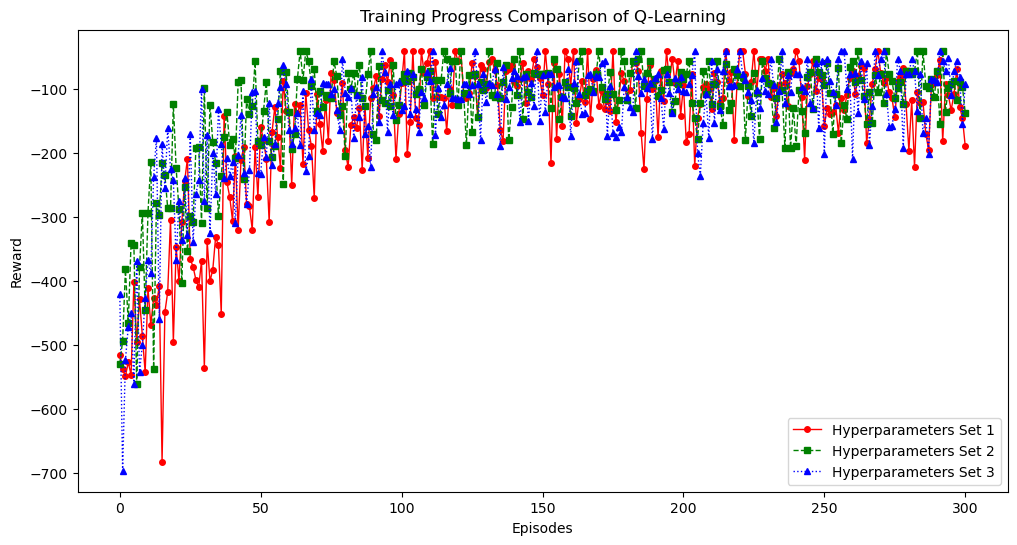

In [73]:
# Plotting the training progress
# do NOT change
plt.figure(figsize=(12, 6))
plt.plot(rewards1, label='Hyperparameters Set 1', color='r', linestyle='-', linewidth=1, marker='o', markersize=4)
plt.plot(rewards2, label='Hyperparameters Set 2', color='g', linestyle='--', linewidth=1, marker='s', markersize=4)
plt.plot(rewards3, label='Hyperparameters Set 3', color='b', linestyle=':', linewidth=1, marker='^', markersize=4)
plt.xlabel('Episodes')
plt.ylabel('Reward')
plt.title('Training Progress Comparison of Q-Learning')
plt.legend()
plt.show()

## 2. Testing Performance

In [66]:
def testing_Q_Learning(mg, Q, horizon):
    mg.reset(testing=True)
    total_cost = 0
    costs = []  # List to store single-step info
    states = []
    actions = []  

    for i in range(horizon):
        net_load = round(mg.load - mg.pv) # mg.load and mg.pv can be used to get load and pv at a given time
        soc = round(mg.battery.soc, 1) # mg.battery.soc to get the charge of the battery
        s = (net_load, soc) # states combination of new states
        a = max_dict(Q[s])[0] # action with max value for the given state (refer helper_function.py for a hint)

        if soc == 0.2 and a == 1:  # do NOT change
            a = 2                  # do NOT change
        if soc == 1 and a == 0:    # do NOT change
            a = 1                  # do NOT change

        actions.append(a)  # Store the action
        action = actions_agent(mg, a)
        status = mg.run(action)
        cost = mg.get_cost()

        if a == 0:               # do NOT change
            cost -= 35           # do NOT change

        total_cost += cost
        costs.append(total_cost)
        states.append((int(net_load), round(mg.battery.soc, 1))) # add two variables of the states here

        net_load = round(mg.load - mg.pv)
        soc = round(mg.battery.soc, 1)
        s_ = (net_load, soc)
        a_ = max_dict(Q[s_])[0]

        s, a = s_, a_

    return costs, states, actions

In [77]:
costs, states, actions = testing_Q_Learning(mg0, Q1, 48) # hint: use the set of hyperparameters you consider optimal from Q1, Q2, Q3

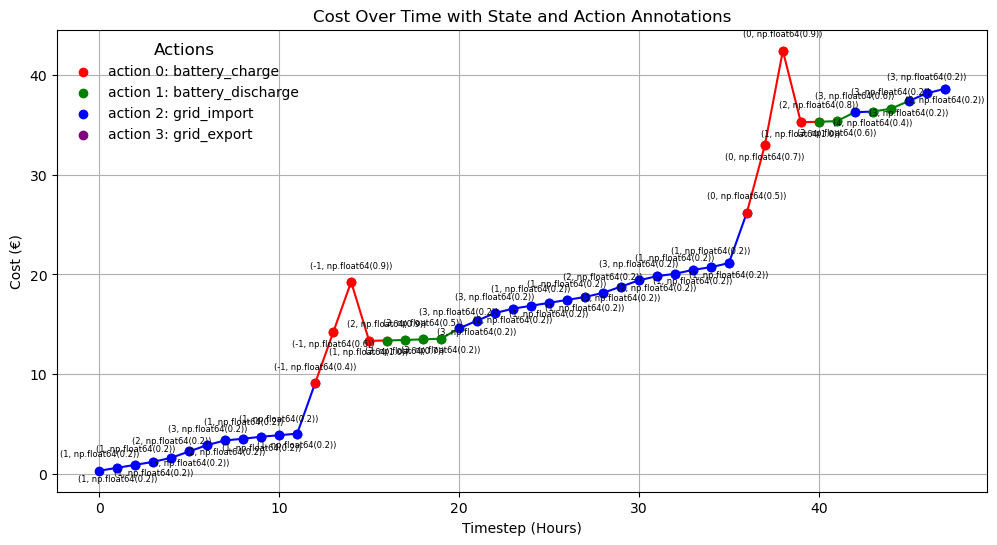

Total cost is: 38.64 €


In [76]:
# Plotting the testing performance using your chosen set of hyperparameters
# do Not Change
# do Not Change
plt.figure(figsize=(12, 6))
time_steps = range(len(costs))

colors = {0: 'red', 1: 'green', 2: 'blue', 3: 'purple'}
actions_legend = ['battery_charge', 'battery_discharge', 'grid_import', 'grid_export']

for i, (state, action) in enumerate(zip(states, actions)):
    plt.plot(time_steps[i:i+2], costs[i:i+2], color=colors[action], marker='o')
    offset_y = 10 if i % 2 == 0 else -10
    plt.annotate(str(state), (time_steps[i], costs[i]), textcoords="offset points", 
                 xytext=(0, offset_y), ha='center', fontsize=6)
for action, color in colors.items():
    plt.scatter([], [], color=color, label=f"action {action}: {actions_legend[action]}")

plt.legend(loc='upper left', title='Actions', frameon=False, title_fontsize='large')
plt.xlabel('Timestep (Hours)')
plt.ylabel('Cost (€)')
plt.title('Cost Over Time with State and Action Annotations')
plt.grid(True)
plt.show()

# Print the cost with two decimal places
total_cost = costs[-1]
print(f"Total cost is: {total_cost:.2f} €")
# do Not Change
# do Not Change

## 3. Questions and discussion

## Please write down your answers for the following 4 questions:

### *1. Base on above training figure, please explain how you choose the optimal set of hyperparameters for testing from the three sets.*

### *2. Please explain why SARSA is an on-policy learning and Q-learning is an off-policy learning*

Answer:  SARSA is an on-policy learning because it updates using the action based on the nest action taken based on the same policy,. It is called on-policy learning because th policy being evaluated and tested are the same. 
Equation: Q[s][a] += alpha*(r + gamma*Q[s'][a'] - Q[s][a]), where a' follows the same epsilon-greedy policy.

Q-learning updates the by checking for local maxima regardless of what action is taken. It evaluates the greedy policy while following exploratory plocy, hence it is a off-policy learning. 
Equation: Q[s][a] += alpha * (r + gamma * max_dict(Q[s_])[1] - Q[s][a])  updates using max Q[s'] 